In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [2]:
path = "uber-raw-data-apr14.csv"

In [3]:
df = pd.read_csv(path, delimiter = ',')

In [5]:
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


<Axes: >

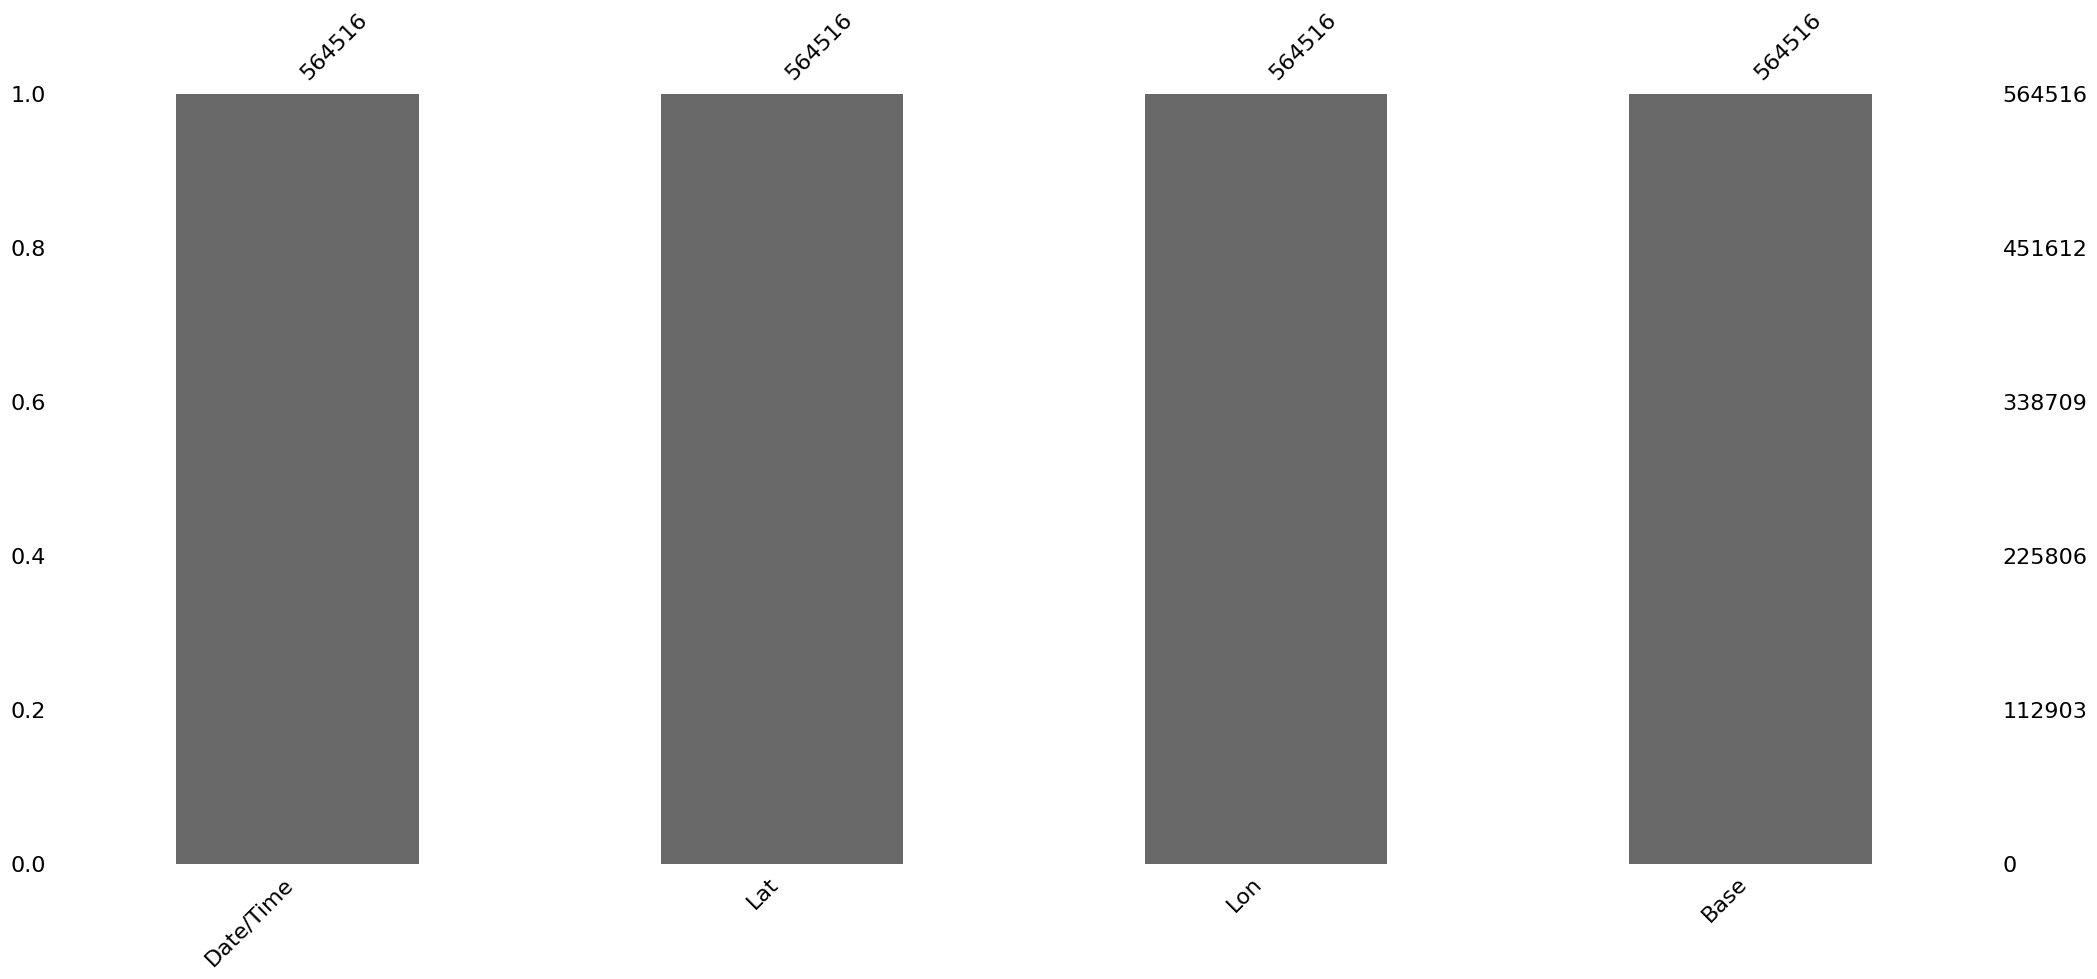

In [10]:
msno.bar(df)

In [12]:
df['Date/Time'] = pd.to_datetime(df['Date/Time']) #Note : It takes time depending on your machines memory
df.head()

,Date/Time,Lat,Lon,Base
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512


In [14]:
def get_dom(dt):
    return dt.day #.day is an attribute

In [15]:
df['day'] = df['Date/Time'].map(get_dom)

In [16]:
def get_weekday(dt):
    return dt.weekday() #.weekday() is a method

In [17]:
df['weekday']= df['Date/Time'].map(get_weekday)

In [18]:
def get_hour(dt):
    return dt.hour #.hour is an attribute

In [19]:
df['hour'] = df['Date/Time'].map(get_hour)

Text(0.5, 0, 'Days of the month')

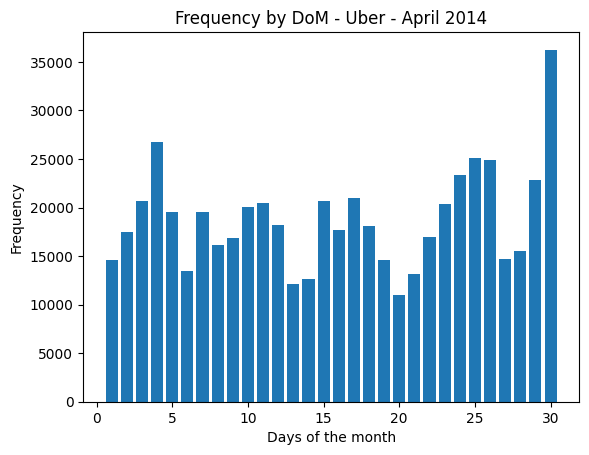

In [20]:
hist = df["day"].plot.hist(bins = 30, rwidth = 0.8, range=(0.5,30.5), title = "Frequency by DoM - Uber - April 2014")
plt.xlabel('Days of the month')
#binsint or sequence or str, default: rcParams["hist.bins"] (default: 10)
#If bins is an integer, it defines the number of equal-width bins in the range.
#If bins is a sequence, it defines the bin edges, including the left edge of the first bin
#and the right edge of the last bin; in this case, bins may be unequally spaced.

In [21]:
def count_rows(rows):
    return len(rows)

In [22]:
by_date = df.groupby('day').apply(count_rows)
by_date

C:\Users\Gérémy\AppData\Local\Temp\ipykernel_13924\1814074559.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_date = df.groupby('day').apply(count_rows)


day
1     14546
2     17474
3     20701
4     26714
5     19521
6     13445
7     19550
8     16188
9     16843
10    20041
11    20420
12    18170
13    12112
14    12674
15    20641
16    17717
17    20973
18    18074
19    14602
20    11017
21    13162
22    16975
23    20346
24    23352
25    25095
26    24925
27    14677
28    15475
29    22835
30    36251
dtype: int64

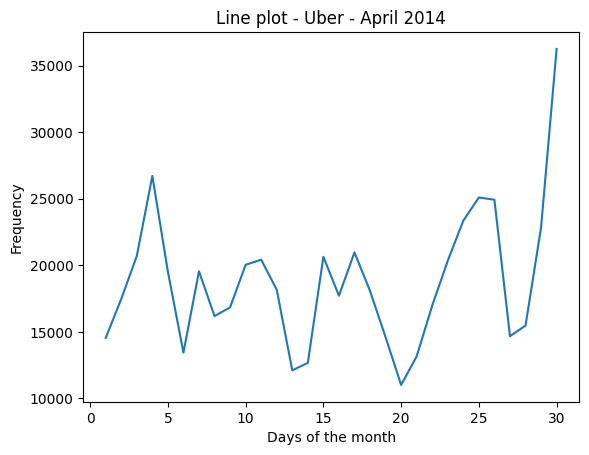

In [23]:
plt.title('Line plot - Uber - April 2014')
plt.xlabel('Days of the month')
plt.ylabel('Frequency')
plt.plot(by_date);

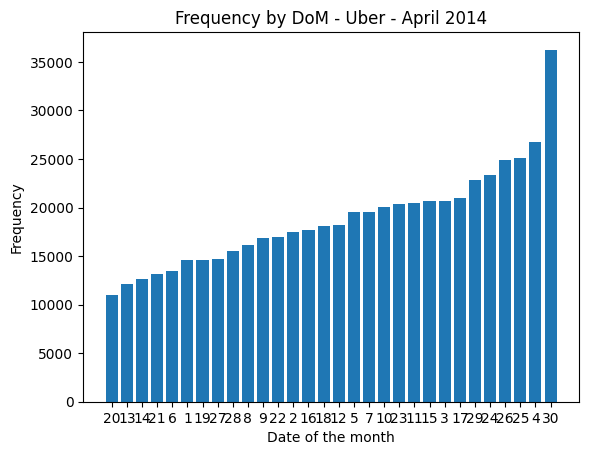

In [24]:
plt.bar(range(1, 31), by_date.sort_values())
plt.xticks(range(1, 31), by_date.sort_values().index)
plt.xlabel('Date of the month')
plt.ylabel('Frequency')
plt.title('Frequency by DoM - Uber - April 2014');
 

In [25]:
plt.figure(figsize = (25, 15))

<Figure size 2500x1500 with 0 Axes>

<Figure size 2500x1500 with 0 Axes>

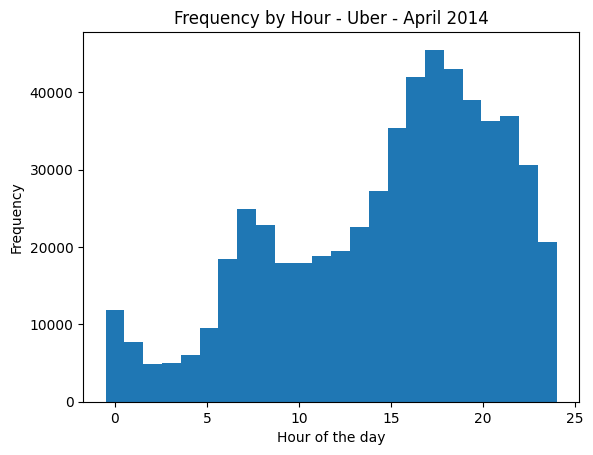

In [28]:
plt.hist(df.hour, bins = 24, range = (-0.5, 24))
plt.xlabel('Hour of the day')
plt.ylabel('Frequency')
plt.title('Frequency by Hour - Uber - April 2014');

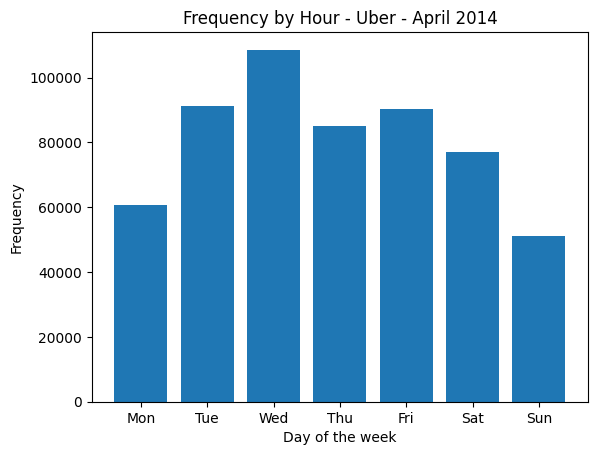

In [29]:
plt.hist(df.weekday, bins = 7, rwidth = 0.8, range = (-.5, 6.5))
plt.xlabel('Day of the week')
plt.ylabel('Frequency')
plt.title('Frequency by Hour - Uber - April 2014')
plt.xticks(np.arange(7), 'Mon Tue Wed Thu Fri Sat Sun'.split())
plt.show()

In [30]:
df2 = df.groupby(['weekday', 'hour']).apply(count_rows).unstack()
df2.head()
#Pandas Unstack is a function that pivots the level of the indexed columns in a stacked dataframe. 
#A stacked dataframe is usually a result of an aggregated groupby function in pandas.
#Stack() sets the columns to a new level of hierarchy whereas Unstack() pivots the indexed column.

C:\Users\Gérémy\AppData\Local\Temp\ipykernel_13924\2720920564.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df2 = df.groupby(['weekday', 'hour']).apply(count_rows).unstack()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday,,,,,,,,,,,,,,,,,,,,,
0,518,261,238,571,1021,1619,2974,3888,3138,2211,...,3117,3818,4962,5574,4725,4386,3573,3079,1976,1091
1,765,367,304,516,887,1734,3766,5304,4594,2962,...,4489,6042,7521,8297,7089,6459,6310,5993,3614,1948
2,899,507,371,585,1003,1990,4230,5647,5242,3846,...,5438,7071,8213,9151,8334,7794,7783,6921,4845,2571
3,792,459,342,567,861,1454,3179,4159,3616,2654,...,4083,5182,6149,6951,6637,5929,6345,6585,5370,2909
4,1367,760,513,736,932,1382,2836,3943,3648,2732,...,4087,5354,6259,6790,7258,6247,5165,6265,6708,5393


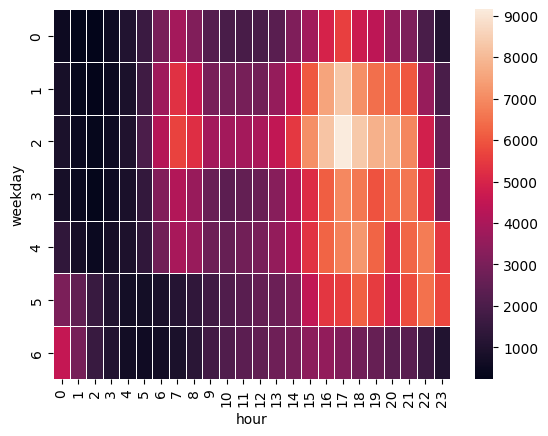

In [31]:
sns.heatmap(df2, linewidths = .5);

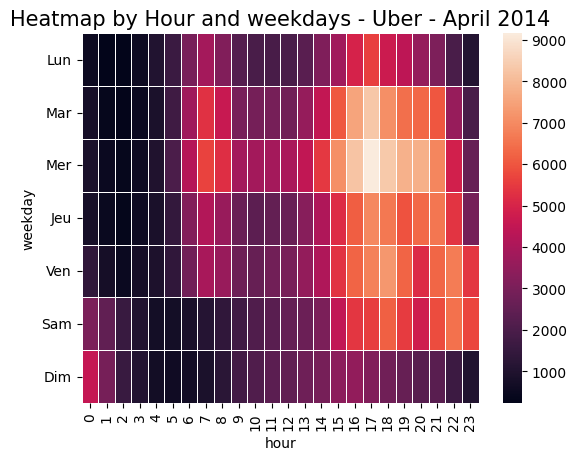

In [32]:
heatmap = sns.heatmap(df2, linewidths = .5);
#Annoted heatmap
plt.title('Heatmap by Hour and weekdays - Uber - April 2014',fontsize=15)
heatmap.set_yticklabels(('Lun Mar Mer Jeu Ven Sam Dim').split(), rotation='horizontal');

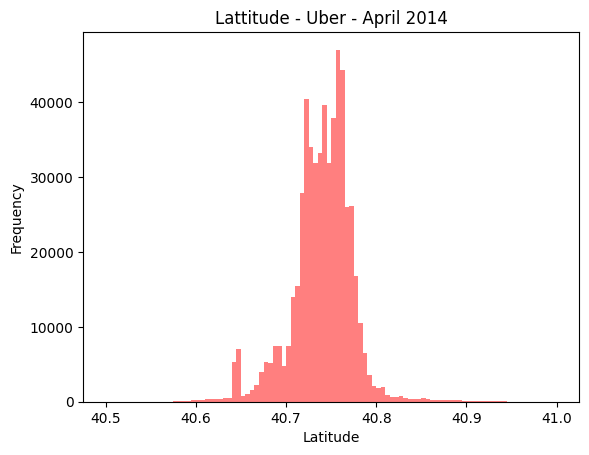

In [33]:
#Lat :
plt.hist(df['Lat'], bins = 100, range = (40.5, 41), color = 'r',alpha = 0.5, label = 'Latitude')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.title('Lattitude - Uber - April 2014');
plt.show()

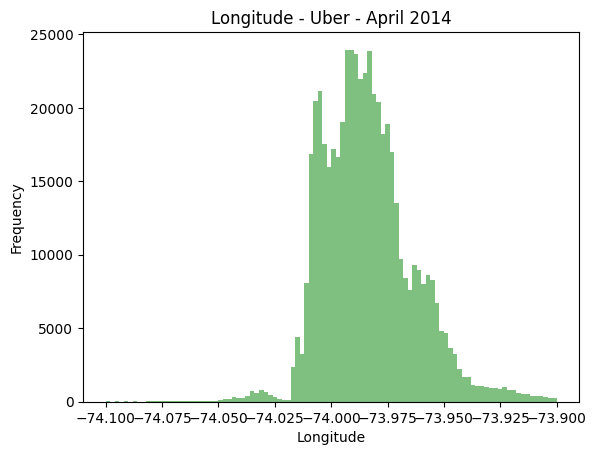

In [34]:
#Lon :
plt.hist(df['Lon'], bins = 100, range = (-74.1, -73.9), color = 'g', alpha = 0.5, label = 'Longitude')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.title('Longitude - Uber - April 2014');
plt.show()

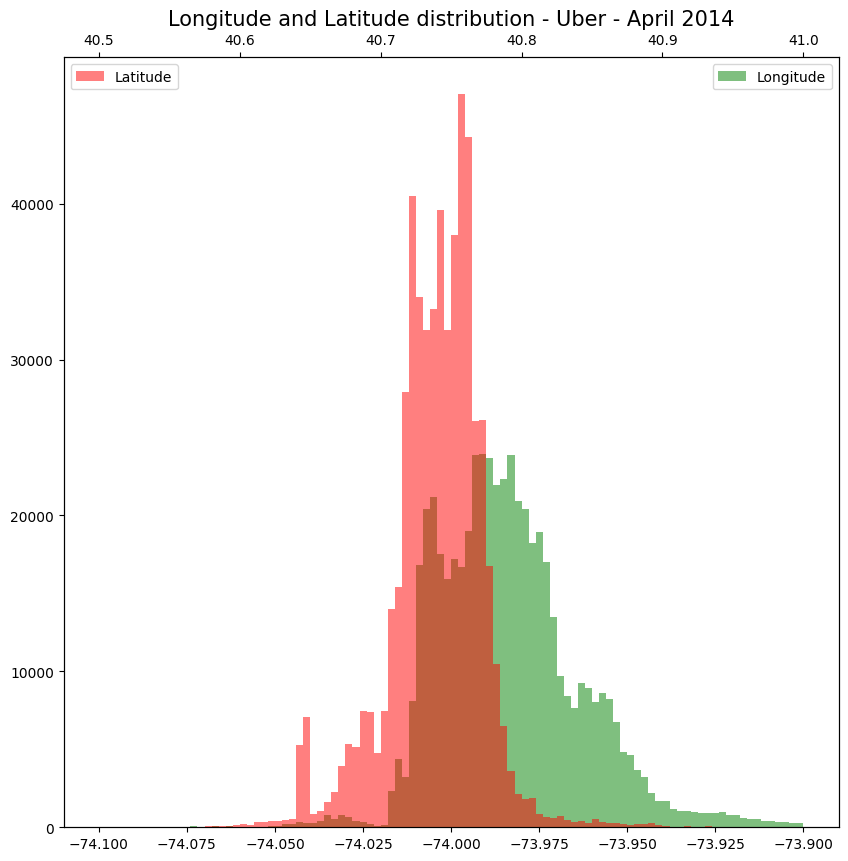

In [35]:
plt.figure(figsize=(10, 10), dpi=100)
plt.title('Longitude and Latitude distribution - Uber - April 2014',fontsize=15)
plt.hist(df['Lon'], bins = 100, range = (-74.1, -73.9), color = 'g', alpha = 0.5, label = 'Longitude')
plt.legend(loc = 'best')
plt.twiny()
plt.hist(df['Lat'], bins = 100, range = (40.5, 41), color = 'r',alpha = 0.5, label = 'Latitude')
plt.legend(loc = 'upper left')
plt.show()

(40.7, 40.9)

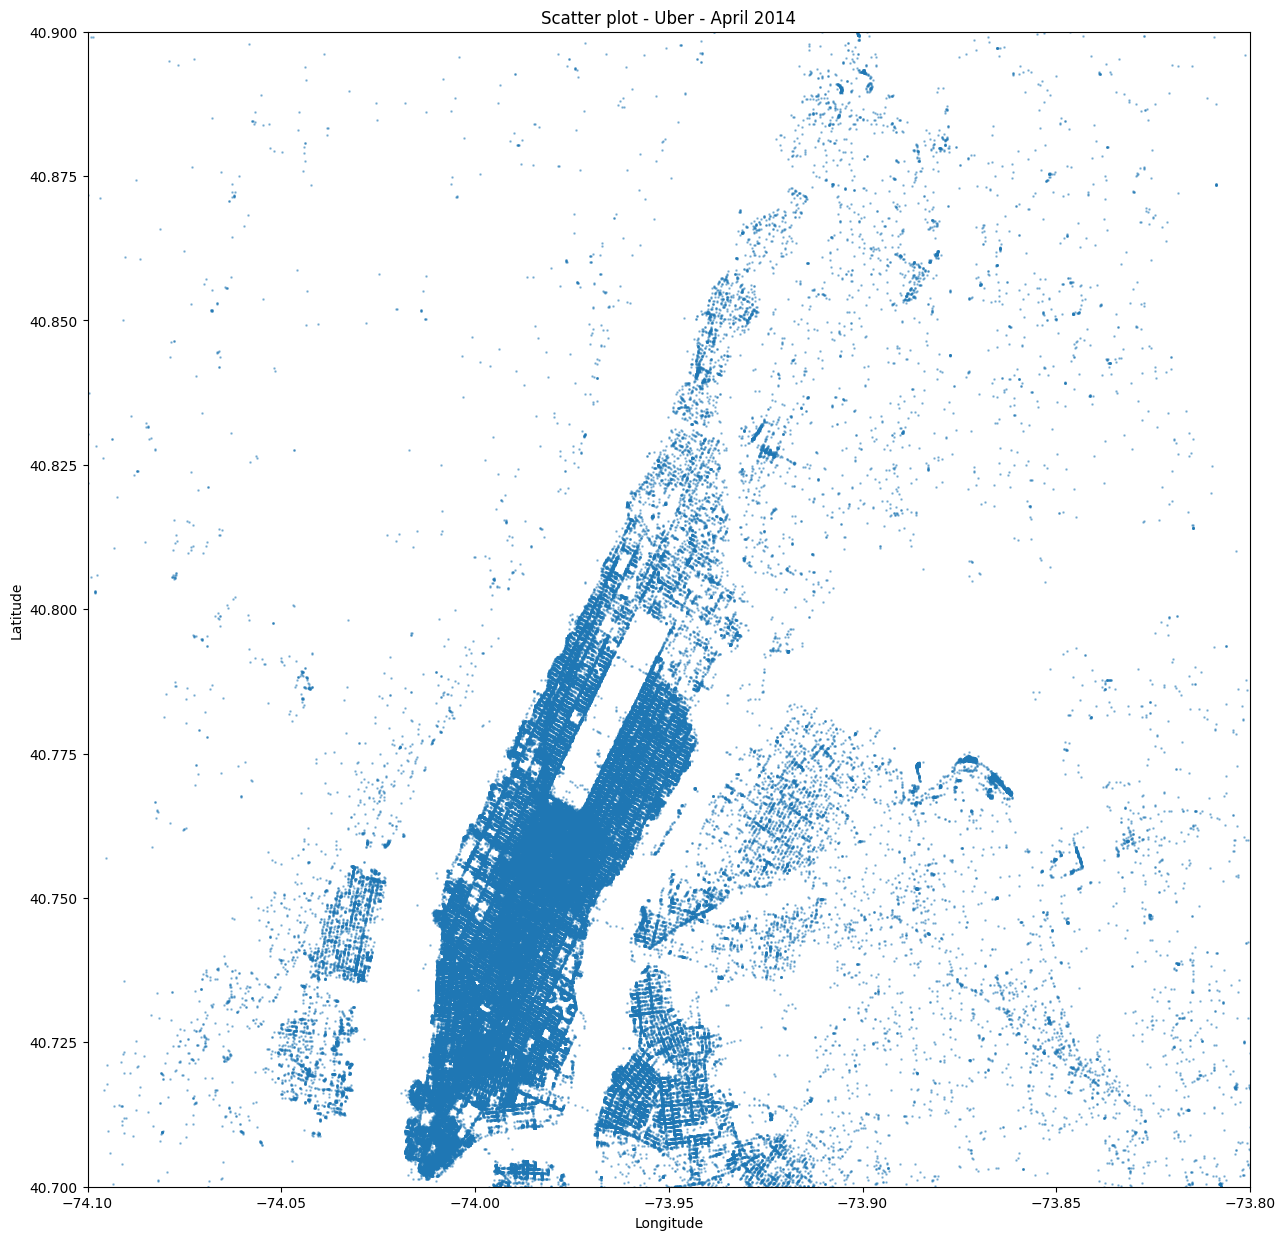

In [37]:
plt.figure(figsize=(15, 15), dpi=100)
plt.title('Scatter plot - Uber - April 2014')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.scatter(df['Lon'],df['Lat'],s=0.8,alpha=0.4) #Without list also shows the same plot
plt.xlim(-74.1, -73.8)
plt.ylim(40.7, 40.9)